In [1]:
# 1. 당뇨병 여부를 예측하는 이진 분류 모델을 구축하시오.
# 필요한 전처리 후 표준화하시오.
# 입력층, 은닉층(2개), 출력층으로 구현하고, ReLu, Sigmoid함수를 사용하시오.
# 필요한 손실함수와 옵티마이저(Adam) 설정하시오.
# 모델학습(에폭 수 자유롭게), 출력값이 0.5 이상이면 1, 미만이면 0으로 분류하시오.
# 손실을 시각화하고 해석하시오.
# 평가모드로 전환해 정확도 출력하시오.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('./diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
x=df.drop('Outcome', axis=1).values
y=df['Outcome'].values
print(x,y)

[[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]] [1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
print(X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


In [9]:
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1) 
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

In [10]:
# 입력층, 은닉층(2개), 출력층으로 구현하고, ReLu, Sigmoid함수를 사용하시오.
class DiabetesModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.fc1=nn.Linear(input_dim, 64)
        self.fc2=nn.Linear(64, 1)
        self.relu=nn.ReLU()
        self.sigmoid=nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

In [11]:
# 필요한 손실함수와 옵티마이저(Adam) 설정하시오.
input_dim = X_train.shape[1]
model = DiabetesModel(input_dim)
bceloss = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [12]:
epochs = 1000

train_accs, train_losses = [], []
test_accs, test_losses = [], []

In [13]:
# 모델학습(에폭 수 자유롭게), 출력값이 0.5 이상이면 1, 미만이면 0으로 분류하시오.
for epoch in range(epochs):
    model.train() 
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = bceloss(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    train_pred = (outputs > 0.5).float()
    train_acc = (train_pred == y_train_t).float().mean()
    train_accs.append(train_acc.item())

    if (epoch + 1) % 100 == 0:
        current_train_loss = train_losses[-1]
        current_train_acc = train_accs[-1]

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {current_train_loss:.4f}")
        print(f"Train Acc: {current_train_acc*100:.2f}%")
        print("-" * 30)

Epoch [100/1000]
Train Loss: 0.6571
Train Acc: 65.15%
------------------------------
Epoch [200/1000]
Train Loss: 0.6237
Train Acc: 66.45%
------------------------------
Epoch [300/1000]
Train Loss: 0.5951
Train Acc: 68.08%
------------------------------
Epoch [400/1000]
Train Loss: 0.5703
Train Acc: 71.82%
------------------------------
Epoch [500/1000]
Train Loss: 0.5487
Train Acc: 72.96%
------------------------------
Epoch [600/1000]
Train Loss: 0.5303
Train Acc: 73.78%
------------------------------
Epoch [700/1000]
Train Loss: 0.5148
Train Acc: 74.27%
------------------------------
Epoch [800/1000]
Train Loss: 0.5014
Train Acc: 74.92%
------------------------------
Epoch [900/1000]
Train Loss: 0.4897
Train Acc: 76.06%
------------------------------
Epoch [1000/1000]
Train Loss: 0.4796
Train Acc: 76.55%
------------------------------


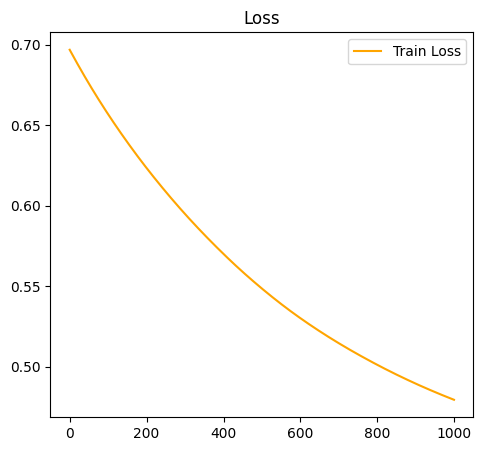

In [14]:
# 손실을 시각화하고 해석하시오.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', color='orange')
plt.title('Loss')
plt.legend()

plt.show()

In [15]:
# 평가모드로 전환해 정확도 출력하시오.
for epoch in range(epochs):
    model.eval() 
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = bceloss(test_outputs, y_test_t)
        test_losses.append(test_loss.item())
        
        test_pred = (test_outputs > 0.5).float()
        test_acc = (test_pred == y_test_t).float().mean()
        test_accs.append(test_acc.item())

        if (epoch + 1) % 100 == 0:
            current_test_loss = test_losses[-1]
            current_test_acc = test_accs[-1]
    
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"Test Loss: {current_test_loss:.4f}")
            print(f"Test Acc: {current_test_acc*100:.2f}%")
            print("-" * 30)

Epoch [100/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [200/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [300/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [400/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [500/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [600/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [700/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [800/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [900/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------
Epoch [1000/1000]
Test Loss: 0.5159
Test Acc: 77.92%
------------------------------


In [16]:
avg_train_loss = sum(train_losses) / len(train_losses)
avg_test_loss = sum(test_losses) / len(test_losses)
avg_train_acc = sum(train_accs) / len(train_accs)
avg_test_acc = sum(test_accs) / len(test_accs)

print(f"Avg Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
print(f"Avg Acc: {avg_train_acc*100:.2f}% | Test Acc: {avg_test_acc*100:.2f}%")

Avg Loss: 0.5615 | Test Loss: 0.5159
Avg Acc: 71.35% | Test Acc: 77.92%


In [17]:
np.save('train_losses.npy', train_losses)
np.save('test_losses.npy', test_losses)

In [18]:
data2 = np.load('train_losses.npy')
data2

array([0.69675726, 0.69631827, 0.69588006, 0.69544268, 0.69500601,
       0.69457012, 0.69413489, 0.69370013, 0.69326615, 0.69283313,
       0.69240075, 0.69196916, 0.6915381 , 0.69110781, 0.69067824,
       0.69024944, 0.68982124, 0.6893937 , 0.68896693, 0.68854105,
       0.68811595, 0.68769181, 0.68726838, 0.68684578, 0.68642378,
       0.68600255, 0.6855821 , 0.68516254, 0.6847437 , 0.68432581,
       0.68390846, 0.68349195, 0.68307644, 0.68266165, 0.68224794,
       0.68183517, 0.68142325, 0.68101239, 0.68060237, 0.68019319,
       0.67978489, 0.67937714, 0.67897046, 0.67856449, 0.67815924,
       0.677755  , 0.67735153, 0.6769489 , 0.67654705, 0.67614609,
       0.67574573, 0.67534637, 0.67494774, 0.67454994, 0.67415291,
       0.67375684, 0.67336154, 0.67296714, 0.67257357, 0.67218095,
       0.67178899, 0.67139792, 0.67100763, 0.6706183 , 0.67022985,
       0.66984212, 0.66945529, 0.66906917, 0.66868377, 0.66829902,
       0.66791511, 0.66753197, 0.66714954, 0.6667679 , 0.66638